In [31]:
import pandas as pd


In [32]:
df = pd.read_csv("bank-additional-full.csv", sep=";")


In [33]:
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [34]:
df.shape


(41188, 21)

In [35]:
df.columns


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [36]:
df.dtypes


age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [37]:
df['y'].value_counts()


y
no     36548
yes     4640
Name: count, dtype: int64

In [38]:
df_work = df.copy()

In [39]:
df_work.shape


(41188, 21)

In [40]:
df_work = df_work.drop(columns=['duration','y'])

In [41]:
df_work.shape


(41188, 19)

In [42]:
df_work.columns


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed'],
      dtype='object')

In [43]:
numeric_cols = df_work.select_dtypes(include=['int64', 'float64']).columns
numeric_cols


Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [44]:
catogorical_cols = df_work.select_dtypes(include=['object']).columns
catogorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

In [45]:
df_work['contacted_before'] = (df_work['pdays'] != 999).astype(int)

In [46]:
df_work[['pdays', 'contacted_before']].sample(10)


,pdays,contacted_before
11941,999,0
4577,999,0
12509,999,0
6014,999,0
1366,999,0
38539,6,1
37758,3,1
8194,999,0
16287,999,0
9264,999,0


In [47]:
df_work = df_work.drop(columns=['pdays'])

In [48]:
df_work.columns


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'contacted_before'],
      dtype='object')

In [49]:
df_work.shape


(41188, 19)

In [50]:
df_work['default'].value_counts()


default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [51]:
df_work['housing'].value_counts()



housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

In [52]:
df_work['loan'].value_counts()

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

In [53]:
yes_no_map = {'yes': 1, 'no': 0}

df_work['default'] = df_work['default'].map(yes_no_map)
df_work['housing'] = df_work['housing'].map(yes_no_map)
df_work['loan'] = df_work['loan'].map(yes_no_map)


In [54]:
df_work[['default', 'housing', 'loan']].head(10)


,default,housing,loan
0,0.0,0.0,0.0
1,NaN,0.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,1.0
5,NaN,0.0,0.0
6,0.0,0.0,0.0
7,NaN,0.0,0.0
8,0.0,1.0,0.0
9,0.0,1.0,0.0


In [55]:
df_work = pd.get_dummies(
    df_work,
    columns=[
        'job',
        'marital',
        'education',
        'poutcome',
        'contact',
        'month',
        'day_of_week'
    ],
    drop_first=True
)


In [56]:
df_work.shape


(41188, 49)

In [57]:
df_work.head()


,age,default,housing,loan,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,56,0.0,0.0,0.0,1,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,False,True,False,False,False
1,57,NaN,0.0,0.0,1,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,False,True,False,False,False
2,37,0.0,1.0,0.0,1,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,False,True,False,False,False
3,40,0.0,0.0,0.0,1,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,False,True,False,False,False
4,56,0.0,0.0,1.0,1,0,1.1,93.994,-36.4,4.857,...,False,False,True,False,False,False,True,False,False,False


In [58]:
df_work.dtypes

age                                int64
default                          float64
housing                          float64
loan                             float64
campaign                           int64
previous                           int64
emp.var.rate                     float64
cons.price.idx                   float64
cons.conf.idx                    float64
euribor3m                        float64
nr.employed                      float64
contacted_before                   int64
job_blue-collar                     bool
job_entrepreneur                    bool
job_housemaid                       bool
job_management                      bool
job_retired                         bool
job_self-employed                   bool
job_services                        bool
job_student                         bool
job_technician                      bool
job_unemployed                      bool
job_unknown                         bool
marital_married                     bool
marital_single  

In [59]:
#df_work = df_work.astype(int)


In [60]:
bool_cols = df_work.select_dtypes(include='bool').columns
bool_cols


Index(['job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown',
       'poutcome_nonexistent', 'poutcome_success', 'contact_telephone',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed'],
      dtype='object')

In [61]:
df_work[bool_cols] = df_work[bool_cols].astype(int)


In [62]:
df_work.dtypes


age                                int64
default                          float64
housing                          float64
loan                             float64
campaign                           int64
previous                           int64
emp.var.rate                     float64
cons.price.idx                   float64
cons.conf.idx                    float64
euribor3m                        float64
nr.employed                      float64
contacted_before                   int64
job_blue-collar                    int64
job_entrepreneur                   int64
job_housemaid                      int64
job_management                     int64
job_retired                        int64
job_self-employed                  int64
job_services                       int64
job_student                        int64
job_technician                     int64
job_unemployed                     int64
job_unknown                        int64
marital_married                    int64
marital_single  

In [63]:
from sklearn.preprocessing import StandardScaler


In [64]:
scaler = StandardScaler()


In [65]:
scaled_array = scaler.fit_transform(df_work)


In [66]:
import pandas as pd

scaled_df = pd.DataFrame(
    scaled_array,
    columns=df_work.columns
)


In [67]:
scaled_df.head()


,age,default,housing,loan,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,1.533034,-0.009595,-1.076397,-0.428993,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067
1,1.628993,NaN,-1.076397,-0.428993,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067
2,-0.290186,-0.009595,0.929026,-0.428993,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067
3,-0.002309,-0.009595,-1.076397,-0.428993,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067
4,1.533034,-0.009595,-1.076397,2.331038,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067


In [68]:
df_work[['default', 'housing', 'loan']] = df_work[['default', 'housing', 'loan']].fillna(0)


In [69]:
df_work.isna().sum()


age                              0
default                          0
housing                          0
loan                             0
campaign                         0
previous                         0
emp.var.rate                     0
cons.price.idx                   0
cons.conf.idx                    0
euribor3m                        0
nr.employed                      0
contacted_before                 0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown                      0
marital_married                  0
marital_single                   0
marital_unknown                  0
education_basic.6y               0
education_basic.9y               0
education_high.schoo

In [70]:
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_work)

scaled_df = pd.DataFrame(
    scaled_array,
    columns=df_work.columns
)


In [71]:
scaled_df.head()


,age,default,housing,loan,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,1.533034,-0.008535,-1.048877,-0.422872,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067
1,1.628993,-0.008535,-1.048877,-0.422872,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067
2,-0.290186,-0.008535,0.953401,-0.422872,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067
3,-0.002309,-0.008535,-1.048877,-0.422872,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067
4,1.533034,-0.008535,-1.048877,2.364781,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,...,-0.385042,-0.115907,1.411155,-0.332532,-0.133197,-0.118462,1.959,-0.514581,-0.494394,-0.496067


In [72]:
from sklearn.cluster import KMeans


In [73]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)


In [74]:
kmeans.fit(scaled_df)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [75]:
cluster_labels = kmeans.labels_
cluster_labels[:10]


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [76]:
scaled_df['cluster'] = cluster_labels

In [77]:
scaled_df['cluster'].value_counts()


cluster
2    17378
1    13546
0    10264
Name: count, dtype: int64

In [78]:
scaled_df.columns


Index(['age', 'default', 'housing', 'loan', 'campaign', 'previous',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'contacted_before', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'poutcome_nonexistent', 'poutcome_success',
       'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'cluster'],
      dtype='object')

In [79]:
scaled_df = scaled_df.loc[:, ~scaled_df.columns.duplicated()]


In [80]:
scaled_df.columns


Index(['age', 'default', 'housing', 'loan', 'campaign', 'previous',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'contacted_before', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'poutcome_nonexistent', 'poutcome_success',
       'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'cluster'],
      dtype='object')

In [81]:
scaled_df.columns.value_counts()


age                              1
month_dec                        1
education_basic.9y               1
education_high.school            1
education_illiterate             1
education_professional.course    1
education_university.degree      1
education_unknown                1
poutcome_nonexistent             1
poutcome_success                 1
contact_telephone                1
month_aug                        1
month_jul                        1
default                          1
month_jun                        1
month_mar                        1
month_may                        1
month_nov                        1
month_oct                        1
month_sep                        1
day_of_week_mon                  1
day_of_week_thu                  1
day_of_week_tue                  1
day_of_week_wed                  1
education_basic.6y               1
marital_unknown                  1
marital_single                   1
marital_married                  1
housing             

In [82]:
[col for col in scaled_df.columns if 'cluster' in col.lower()]


['cluster']

In [ ]:
#scaled_df = scaled_df.drop(columns=['Cluster'])


KeyError: "['Cluster'] not found in axis"

In [84]:
scaled_df.columns


Index(['age', 'default', 'housing', 'loan', 'campaign', 'previous',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'contacted_before', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'poutcome_nonexistent', 'poutcome_success',
       'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'cluster'],
      dtype='object')

In [85]:
scaled_df['cluster'].value_counts()


cluster
2    17378
1    13546
0    10264
Name: count, dtype: int64

In [86]:
df_analysis = df_work.copy()
df_analysis['cluster'] = scaled_df['cluster']


In [87]:
cluster_summary = df_analysis.groupby('cluster').mean()
cluster_summary


,age,default,housing,loan,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
cluster,,,,,,,,,,,,,,,,,,,,,
0,39.492303,0.000097,0.541017,0.158125,2.773480,0.067615,0.876958,93.667637,-42.455914,4.666359,...,0.000000,0.000000,0.000000,0.348694,0.000000,0.000000,0.200214,0.231586,0.205281,0.207619
1,39.678208,0.000000,0.564373,0.152665,2.091318,0.474605,-2.032312,93.028284,-42.637184,1.178163,...,0.069688,0.040307,0.443378,0.038535,0.048132,0.042079,0.223904,0.216079,0.182563,0.179610
2,40.607722,0.000115,0.482104,0.147140,2.817240,0.000058,1.260289,93.948020,-37.685021,4.908437,...,0.251698,0.000000,0.446714,0.000000,0.003798,0.000000,0.197146,0.190989,0.201980,0.205432


In [88]:
important_cols = [
    'age',
    'campaign',
    'previous',
    'contacted_before',
    'emp.var.rate',
    'euribor3m',
    'nr.employed'
]

cluster_summary[important_cols]


,age,campaign,previous,contacted_before,emp.var.rate,euribor3m,nr.employed
cluster,,,,,,,
0,39.492303,2.773480,0.067615,0.000000,0.876958,4.666359,5216.837169
1,39.678208,2.091318,0.474605,0.111841,-2.032312,1.178163,5072.381197
2,40.607722,2.817240,0.000058,0.000000,1.260289,4.908437,5211.404229


In [89]:
cluster1_df = df_analysis[df_analysis['cluster'] == 1].copy()


In [90]:
cluster1_df.shape


(13546, 50)

In [91]:
import numpy as np


In [92]:
np.random.seed(42)

cluster1_df['variant'] = np.random.choice(
    ['A', 'B'],
    size=len(cluster1_df),
    p=[0.5, 0.5]
)


In [93]:
cluster1_df['variant'].value_counts()


variant
A    6852
B    6694
Name: count, dtype: int64

In [94]:
cluster1_df['y'] = df.loc[cluster1_df.index, 'y']


In [95]:
cluster1_df['converted'] = cluster1_df['y'].map({'yes': 1, 'no': 0})


In [96]:
cluster1_df[['variant', 'y', 'converted']].head()


,variant,y,converted
24013,A,no,0
24108,B,no,0
24264,B,no,0
24279,B,no,0
24397,A,no,0


In [97]:
conversion_summary = (
    cluster1_df
    .groupby('variant')['converted']
    .agg(['sum', 'count', 'mean'])
)

conversion_summary


,sum,count,mean
variant,,,
A,1649,6852,0.240660
B,1656,6694,0.247386


In [98]:
conversion_summary.rename(
    columns={
        'sum': 'conversions',
        'count': 'users',
        'mean': 'conversion_rate'
    },
    inplace=True
)

conversion_summary


,conversions,users,conversion_rate
variant,,,
A,1649,6852,0.240660
B,1656,6694,0.247386


In [99]:
conversion_summary.columns


Index(['conversions', 'users', 'conversion_rate'], dtype='object')

In [100]:
from statsmodels.stats.proportion import proportions_ztest

# number of conversions for A and B
conversions = conversion_summary['conversions'].values

# total users for A and B
users = conversion_summary['users'].values

z_stat, p_value = proportions_ztest(
    count=conversions,
    nobs=users
)

z_stat, p_value


(np.float64(-0.9112986026721495), np.float64(0.3621380624788888))

### REAL-WORLD DATA SCIENCE WORKFLOW using uplift When AB testing inconclusive
A bank gives you historical campaign data

My task: improve future campaign performance safely

Understand data → Segment customers → Profile risk & behavior →
Design experiment → Validate statistically →
Identify who benefits (uplift) → Make targeted decisions


In [101]:
X = scaled_df.drop(columns=['cluster'], errors='ignore')


In [102]:
k_range = range(2, 9)


In [103]:
from sklearn.cluster import KMeans

inertia = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)


In [104]:
from sklearn.metrics import silhouette_score




In production, we almost NEVER compute silhouette on full data.

In [105]:
X_sample = X.sample(n=10000, random_state=42)


In [106]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)


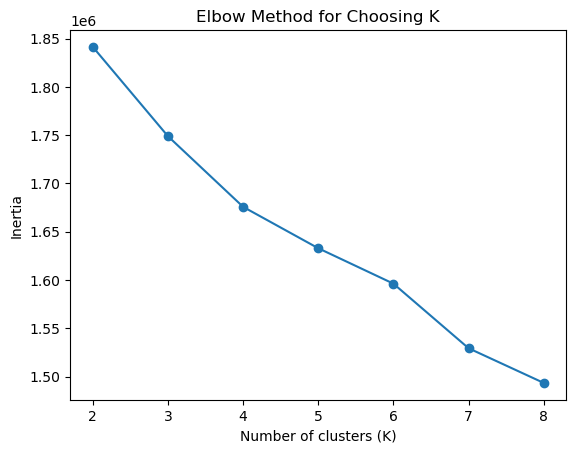

In [107]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")
plt.show()


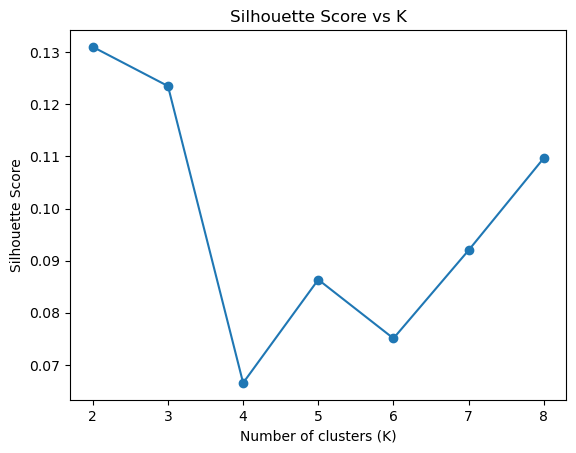

In [ ]:
plt.figure()
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()


In [108]:
df_profile = df_work.copy()
df_profile['cluster'] = scaled_df['cluster']


In [109]:
cluster_profile = (
    df_profile
    .groupby('cluster')
    .agg({
        'default': 'mean',
        'housing': 'mean',
        'loan': 'mean',
        'campaign': 'mean',
        'previous': 'mean',
        'contacted_before': 'mean'
    })
)

cluster_profile


,default,housing,loan,campaign,previous,contacted_before
cluster,,,,,,
0,0.000097,0.541017,0.158125,2.773480,0.067615,0.000000
1,0.000000,0.564373,0.152665,2.091318,0.474605,0.111841
2,0.000115,0.482104,0.147140,2.817240,0.000058,0.000000


In [111]:
uplift_df = df_work.copy()


In [112]:
uplift_df['cluster'] = scaled_df['cluster']


In [113]:
np.random.seed(42)

uplift_df['variant'] = np.random.choice(
    ['A', 'B'],
    size=len(uplift_df),
    p=[0.5, 0.5]
)


In [114]:
uplift_df['y'] = df.loc[uplift_df.index, 'y']
uplift_df['converted'] = uplift_df['y'].map({'yes': 1, 'no': 0})


In [115]:
uplift_df[['cluster', 'variant', 'converted']].head()
uplift_df['variant'].value_counts()


variant
A    20594
B    20594
Name: count, dtype: int64

In [116]:
cluster_variant_summary = (
    uplift_df
    .groupby(['cluster', 'variant'])['converted']
    .mean()
    .reset_index()
)

cluster_variant_summary


,cluster,variant,converted
0,0,A,0.057435
1,0,B,0.058301
2,1,A,0.245200
3,1,B,0.242749
4,2,A,0.044664
5,2,B,0.040617


In [117]:
cluster_uplift = cluster_variant_summary.pivot(
    index='cluster',
    columns='variant',
    values='converted'
)

cluster_uplift


variant,A,B
cluster,,
0,0.057435,0.058301
1,0.245200,0.242749
2,0.044664,0.040617


In [118]:
cluster_uplift['uplift'] = cluster_uplift['B'] - cluster_uplift['A']
cluster_uplift


variant,A,B,uplift
cluster,,,
0,0.057435,0.058301,0.000866
1,0.245200,0.242749,-0.002451
2,0.044664,0.040617,-0.004048


In [119]:
control_df = uplift_df[uplift_df['variant'] == 'A']
treatment_df = uplift_df[uplift_df['variant'] == 'B']


In [120]:
feature_cols = [
    'age', 'default', 'housing', 'loan',
    'campaign', 'previous', 'contacted_before',
    'cluster'
]


In [121]:
X_control = control_df[feature_cols]
y_control = control_df['converted']

X_treat = treatment_df[feature_cols]
y_treat = treatment_df['converted']


In [122]:
from sklearn.linear_model import LogisticRegression

model_A = LogisticRegression(max_iter=1000)
model_A.fit(X_control, y_control)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [123]:
model_B = LogisticRegression(max_iter=1000)
model_B.fit(X_treat, y_treat)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [124]:
p_A = model_A.predict_proba(uplift_df[feature_cols])[:, 1]
p_B = model_B.predict_proba(uplift_df[feature_cols])[:, 1]


In [125]:
uplift_df['predicted_uplift'] = p_B - p_A


In [126]:
uplift_df.sort_values('predicted_uplift', ascending=False).head()


,age,default,housing,loan,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,cluster,variant,y,converted,predicted_uplift
40436,47,0.0,1.0,0.0,2,6,-1.7,94.027,-38.3,0.904,...,0,1,0,0,0,1,A,no,0,0.059639
40710,30,0.0,0.0,0.0,1,5,-1.1,94.199,-37.5,0.877,...,1,0,0,1,0,1,A,no,0,0.057726
40397,27,0.0,1.0,0.0,3,5,-1.7,94.027,-38.3,0.904,...,0,0,1,0,0,1,B,no,0,0.052567
40818,23,0.0,1.0,0.0,2,4,-1.1,94.199,-37.5,0.879,...,1,0,0,0,0,1,A,no,0,0.039038
37353,35,0.0,0.0,1.0,1,3,-2.9,92.201,-31.4,0.883,...,0,0,0,1,0,1,B,yes,1,0.035102


In [127]:
uplift_df['predicted_uplift']


0       -0.009253
1       -0.009589
2       -0.005737
3       -0.004316
4       -0.002898
           ...   
41183   -0.018782
41184   -0.004667
41185   -0.009865
41186   -0.003988
41187   -0.012098
Name: predicted_uplift, Length: 41188, dtype: float64

In [128]:
uplift_df_sorted = uplift_df.sort_values(
    by='predicted_uplift',
    ascending=False
)


In [129]:
top_20_pct = uplift_df_sorted.head(
    int(0.20 * len(uplift_df_sorted))
)


In [130]:
top_20_pct['predicted_uplift'].describe()


count    8237.000000
mean        0.005402
std         0.003620
min         0.002001
25%         0.003028
50%         0.004265
75%         0.006743
max         0.059639
Name: predicted_uplift, dtype: float64